# Fit Rosin-Rammler Curve
* Fits Rosin–Rammler parameters from any two P-values
* Checks the third point
* Plots both curves together

In [2]:
# Define datasets

# --- Dataset A ---
x80_A, F80_A = 365.165, 0.20
x50_A, F50_A = 186.728, 0.50
x20_A, F20_A = 75.735, 0.80

# --- Dataset B ---
x80_B, F80_B = 172.375, 0.20
x50_B, F50_B = 90.836, 0.50
x20_B, F20_B = 13.537, 0.80


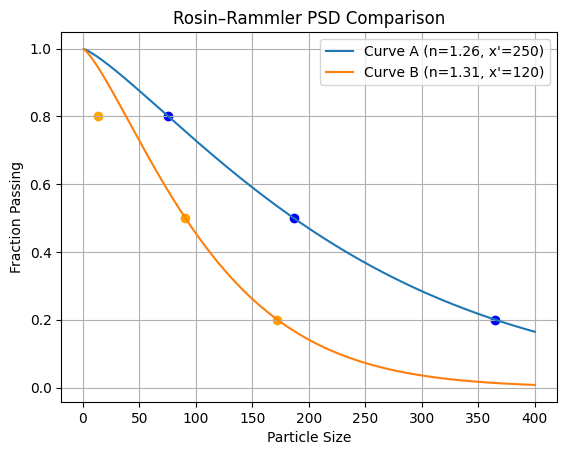

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def fit_rosin_rammler(x1, F1, x2, F2):
    # Solve for n
    n = np.log(-np.log(F1) / -np.log(F2)) / np.log(x1 / x2)
    
    # Solve for x'
    x_prime = x2 / ((-np.log(F2)) ** (1/n))
    
    return n, x_prime

n_A, xprime_A = fit_rosin_rammler(x80_A, F80_A, x50_A, F50_A)

n_B, xprime_B = fit_rosin_rammler(x80_B, F80_B, x50_B, F50_B)

# Rosin–Rammler function
def RR(x, xprime, n):
    return np.exp(-(x / xprime)**n)

# Plotting
x = np.linspace(1, 400, 500)

plt.plot(x, RR(x, xprime_A, n_A), label=f"Curve A (n={n_A:.2f}, x'={xprime_A:.0f})")
plt.plot(x, RR(x, xprime_B, n_B), label=f"Curve B (n={n_B:.2f}, x'={xprime_B:.0f})")

plt.scatter([x80_A, x50_A, x20_A], [F80_A, F50_A, F20_A], color='blue')
plt.scatter([x80_B, x50_B, x20_B], [F80_B, F50_B, F20_B], color='orange')

plt.xlabel("Particle Size")
plt.ylabel("Fraction Passing")
plt.title("Rosin-Rammler PSD Comparison")
plt.legend()
plt.grid(True)
plt.show()
